## **Supervised part of project**

In [1]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import statistics
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import project_utils
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
import shap
from sklearn.inspection import PartialDependenceDisplay
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV

In [117]:
df=pd.read_csv('Listings.csv',encoding="latin1")

# Data pre-processing
from project_utils import features

# Ensure we only use paris listings
df_paris = df[df['city'] == 'Paris'].copy()

# Inlcude amenities for computing amenity score
df_cleaned = df_paris[features+['amenities']].dropna(subset=['review_scores_rating'])

# Impute 'bedrooms' and 'host_count' with the median
df_cleaned['bedrooms'] = df_cleaned['bedrooms'].fillna(df_cleaned['bedrooms'].median())
df_cleaned['host_total_listings_count'] = df_cleaned['host_total_listings_count'].fillna(df_cleaned['host_total_listings_count'].median())

# Uncomment to perform checks
# print(df_cleaned[features].isnull().sum())
df_cleaned = df_cleaned.dropna()
# print(len(df_cleaned))

/var/folders/rd/pqn4crp95cbb0zy1xkn347jh0000gn/T/ipykernel_75790/348450226.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Listings.csv',encoding="latin1")


In [118]:
from project_utils import add_amenity_scores

add_amenity_scores(df_cleaned)

print(df_cleaned[['amenities', 'amenity_expert_score']].head())

# Add amenity score to dataframe
df_cleaned = df_cleaned.drop(columns=['amenities']).astype(float)

                                           amenities  amenity_expert_score
0  ["Heating", "Kitchen", "Washer", "Wifi", "Long...                    39
1  ["Shampoo", "Heating", "Kitchen", "Essentials"...                    52
2  ["Heating", "TV", "Kitchen", "Washer", "Wifi",...                    43
3  ["Heating", "TV", "Kitchen", "Wifi", "Long ter...                    35
4  ["Heating", "TV", "Kitchen", "Essentials", "Ha...                    75


In [119]:
df_cleaned.describe()

,price,accommodates,bedrooms,minimum_nights,maximum_nights,host_total_listings_count,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,...,has_patio_or_balcony,has_pocket_wifi,has_private_entrance,has_refrigerator,has_smoke_alarm,has_stove,has_tv,has_washer,has_wifi,amenity_expert_score
count,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,...,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000
mean,107.358879,3.050082,1.285288,5.404539,682.965958,9.214117,93.076698,9.595649,9.207109,9.687845,...,0.092426,0.066561,0.150560,0.512317,0.737114,0.360756,0.659644,0.784631,0.950356,76.271313
std,195.253084,1.594530,0.867302,50.297801,827.299532,57.899926,8.891415,0.844806,1.104836,0.771975,...,0.289630,0.249263,0.357623,0.499853,0.440205,0.480225,0.473834,0.411082,0.217211,20.181300
min,8.000000,1.000000,1.000000,1.000000,1.000000,0.000000,20.000000,2.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58.000000,2.000000,1.000000,2.000000,30.000000,1.000000,90.000000,9.000000,9.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,63.000000
50%,80.000000,2.000000,1.000000,2.000000,1125.000000,1.000000,95.000000,10.000000,9.000000,10.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,76.000000
75%,115.000000,4.000000,1.000000,4.000000,1125.000000,2.000000,100.000000,10.000000,10.000000,10.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000
max,12000.000000,16.000000,50.000000,9999.000000,99999.000000,1105.000000,100.000000,10.000000,10.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,151.000000


Drop the amenities columns, keep score

In [125]:
cols_to_drop = [col for col in df_cleaned.columns if "has" in col]
df_cleaned=df_cleaned.drop(columns=cols_to_drop)
df_cleaned["log_price"] = np.log(df_cleaned["price"])

In [126]:
df_cleaned.describe()

,price,accommodates,bedrooms,minimum_nights,maximum_nights,host_total_listings_count,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,latitude,longitude,amenity_expert_score,log_price
count,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000,47941.000000
mean,107.358879,1.335650,0.796167,5.404539,682.965958,9.214117,93.076698,9.595649,9.207109,9.687845,9.714378,9.685760,9.277132,48.864166,2.346508,76.271313,4.434188
std,195.253084,0.342772,0.220793,50.297801,827.299532,57.899926,8.891415,0.844806,1.104836,0.771975,0.761999,0.700661,0.941555,0.018207,0.032533,20.181300,0.599204
min,8.000000,0.693147,0.693147,1.000000,1.000000,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,48.815700,2.228680,0.000000,2.079442
25%,58.000000,1.098612,0.693147,2.000000,30.000000,1.000000,90.000000,9.000000,9.000000,10.000000,10.000000,10.000000,9.000000,48.851020,2.326360,63.000000,4.060443
50%,80.000000,1.098612,0.693147,2.000000,1125.000000,1.000000,95.000000,10.000000,9.000000,10.000000,10.000000,10.000000,9.000000,48.865410,2.349210,76.000000,4.382027
75%,115.000000,1.609438,0.693147,4.000000,1125.000000,2.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,48.878830,2.371120,89.000000,4.744932
max,12000.000000,2.833213,3.931826,9999.000000,99999.000000,1105.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,48.904250,2.467050,151.000000,9.392662


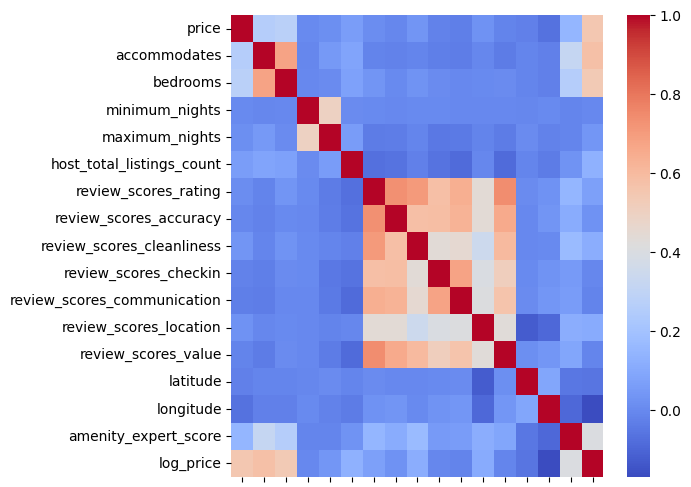

In [127]:
plt.figure(figsize=(6,6))

ax=sns.heatmap(
    df_cleaned.corr(),
    cmap="coolwarm",
)
ax.set_xticklabels([])
plt.show()

Correlation analysis

In [128]:
threshold = df_cleaned["price"].quantile(0.99)

df_cleaned = df_cleaned[df_cleaned["price"] <= threshold]
df_cleaned.describe()

,price,accommodates,bedrooms,minimum_nights,maximum_nights,host_total_listings_count,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,latitude,longitude,amenity_expert_score,log_price
count,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000,47493.000000
mean,97.448340,1.329282,0.791542,5.397680,682.146758,8.938517,93.092919,9.598257,9.207504,9.690102,9.716969,9.685764,9.279746,48.864165,2.346614,76.122776,4.412240
std,66.488999,0.334625,0.213383,50.452635,829.872964,57.457357,8.849661,0.839528,1.102149,0.765790,0.756029,0.697940,0.937840,0.018251,0.032549,20.095577,0.554611
min,8.000000,0.693147,0.693147,1.000000,1.000000,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,48.815700,2.228680,0.000000,2.079442
25%,58.000000,1.098612,0.693147,2.000000,30.000000,1.000000,90.000000,9.000000,9.000000,10.000000,10.000000,10.000000,9.000000,48.850980,2.326460,63.000000,4.060443
50%,80.000000,1.098612,0.693147,2.000000,1125.000000,1.000000,95.000000,10.000000,9.000000,10.000000,10.000000,10.000000,9.000000,48.865380,2.349280,76.000000,4.382027
75%,111.000000,1.609438,0.693147,4.000000,1125.000000,2.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,48.878900,2.371280,89.000000,4.709530
max,500.000000,2.833213,3.931826,9999.000000,99999.000000,1105.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,48.904250,2.467050,148.000000,6.214608


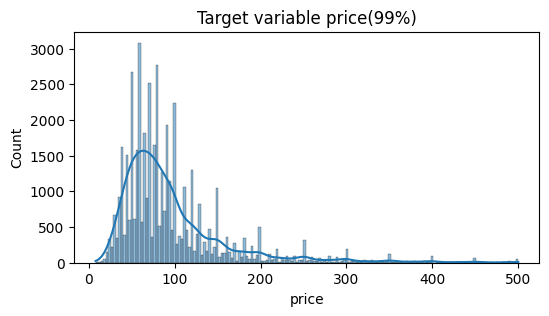

In [129]:
plt.figure(figsize=(6,3))
sns.histplot(df_cleaned["price"], kde=True)
plt.title('Target variable price(99%)')
plt.show()

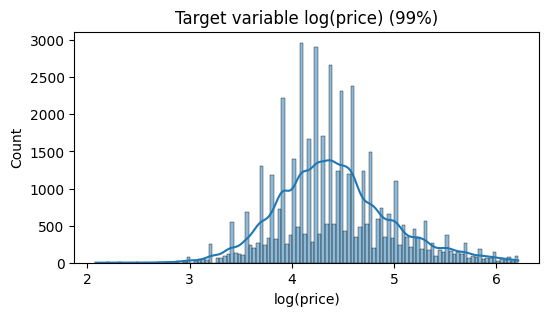

In [130]:
df_cleaned["log_price"] = np.log(df_cleaned["price"])
plt.figure(figsize=(6,3))
sns.histplot(df_cleaned["log_price"], kde=True)
plt.xlabel('log(price)')
plt.title('Target variable log(price) (99%)')
plt.show()

In [84]:

X=df_cleaned.drop(columns=['price','log_price'])
y=np.log(df_cleaned['price'])
#y.head()
#X.head()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
corr = X_train.corr()

plt.figure(figsize=(4,4))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

lasso_pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LassoCV(cv=5, max_iter=10000, random_state=42))])

In [86]:
from sklearn.metrics import mean_squared_error, r2_score
lasso_pred = lasso_pipeline.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)
print('Lasso:')
print("RMSE:", lasso_rmse)
print("R²:", lasso_r2)

Lasso:
RMSE: 0.40068865384159325
R²: 0.42028469457303586


In [87]:
lasso_model = lasso_pipeline.named_steps["model"]
coef = lasso_model.coef_
selected_features = X.columns[coef != 0]
print('Number of selected features:', len(selected_features))

Number of selected features: 15


# Elastic net

In [89]:

enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=20000
    ))
])

enet_pipeline.fit(X_train, y_train)
enet_pred = enet_pipeline.predict(X_test)

enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2 = r2_score(y_test, enet_pred)
print("Enet:")
print("RMSE:", enet_rmse)
print("R²:", enet_r2)

Enet:
RMSE: 0.4006892355343101
R²: 0.4202830113887853


# Ridge

In [90]:

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 50)))
])

ridge_pipeline.fit(X_train, y_train)
ridge_pipeline.score(X_test, y_test)

ridge_pred = ridge_pipeline.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge:")
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

Ridge:
RMSE: 0.40068545394161026
R²: 0.4202939537500605


# PCA regression

In [91]:

pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("reg", LinearRegression())
])

pca_model.fit(X_train, y_train)

pca_pred = pca_model.predict(X_test)

pca_rmse = np.sqrt(mean_squared_error(y_test, pca_pred))
pca_r2 = r2_score(y_test, pca_pred)

print('PCA:')
print("RMSE:", pca_rmse)
print("R²:", pca_r2)

PCA:
RMSE: 0.4016506437216895
R²: 0.41749774414302354


# Nonlinear

In [92]:


rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", RandomForestRegressor())
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print('Random forest regressor')
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random forest regressor
RMSE: 0.3570322781480431
R²: 0.5397268521762202


# GBR

In [93]:


gbr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", GradientBoostingRegressor())
])

gbr_model.fit(X_train, y_train)

gbr_pred = gbr_model.predict(X_test)

gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_r2 = r2_score(y_test, gbr_pred)

print('Gradient Boosting regressor')
print("RMSE:", gbr_rmse)
print("R²:", gbr_r2)

Gradient Boosting regressor
RMSE: 0.35636773630368485
R²: 0.5414386643995844


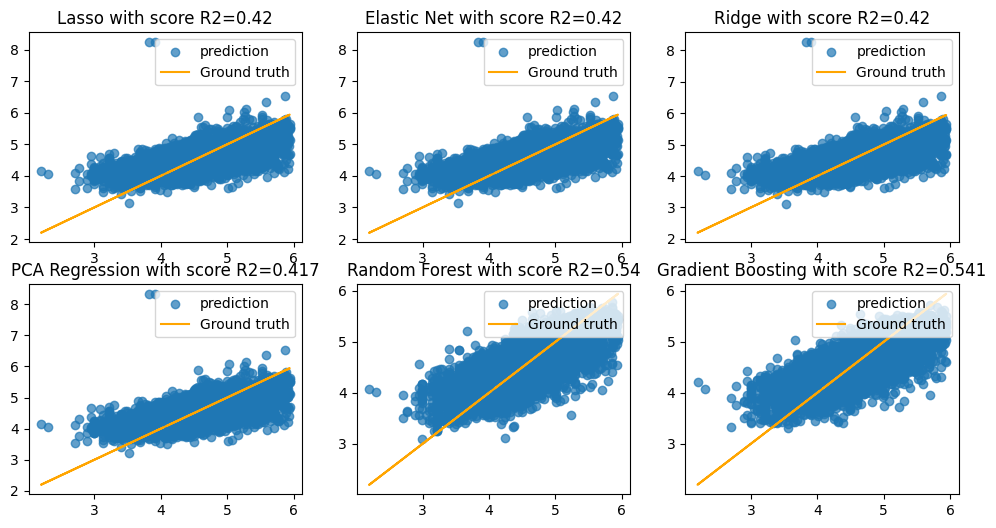

In [94]:
fig,axes=plt.subplots(2,3,figsize=(12,6))
axs=axes.ravel()
preds=[lasso_pred,enet_pred,ridge_pred,pca_pred,rf_pred,gbr_pred]
scores=[lasso_r2,enet_r2,ridge_r2,pca_r2,rf_r2,gbr_r2]
models=['Lasso','Elastic Net','Ridge','PCA Regression','Random Forest','Gradient Boosting']
for i in range(0,len(axs)):
    axs[i].scatter(y_test,preds[i],alpha=0.7,label='prediction')
    axs[i].plot(y_test,y_test,color='orange',label='Ground truth')
    axs[i].legend(loc='upper right')
    axs[i].set_title(f"{models[i]} with score R2={scores[i].round(3)}")

In [143]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf"))
])

param_grid = {
    "krr__alpha": [0.01, 0.1, 1, 10],
    "krr__gamma": [0.001, 0.01, 0.1, 1]
}

model = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

model.fit(X_train, y_train)

print(model.best_params_)
print(model.best_score_)
print(model.score(X_test, y_test))

# Dataset without outliers

In [40]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (y >= lower) & (y <= upper)

df_no_outliers = df_cleaned[mask].copy()

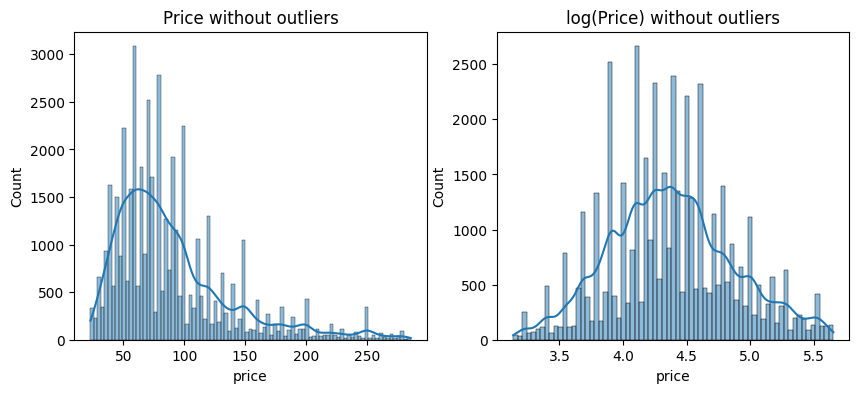

In [41]:
X=df_no_outliers.drop(columns=['price','log_price'])
y=np.log(df_no_outliers['price'])

fig,axs=plt.subplots(1,2,figsize=(10,4))
sns.histplot(df_no_outliers['price'],kde=True,ax=axs[0])
sns.histplot(np.log(df_no_outliers['price']),kde=True,ax=axs[1])
axs[0].set_title('Price without outliers')
axs[1].set_title('log(Price) without outliers')
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

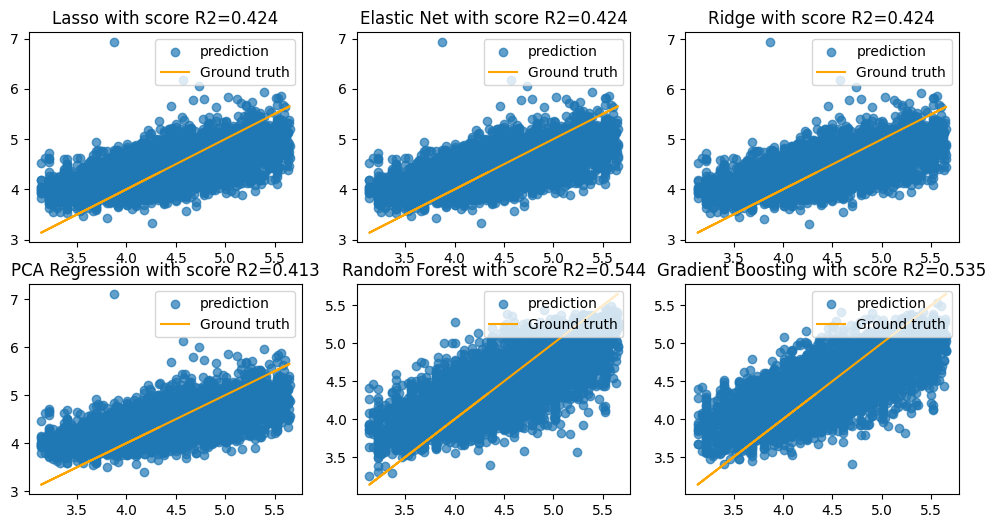

In [42]:
##LASSO
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LassoCV(
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])
lasso_pipeline.fit(X_train,y_train)
lasso_pred = lasso_pipeline.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)
##ENET
enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        max_iter=20000
    ))
])
enet_pipeline.fit(X_train, y_train)
enet_pred = enet_pipeline.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))
enet_r2 = r2_score(y_test, enet_pred)
##RIDGE
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 50)))
])
ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
#PCA
pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("reg", LinearRegression())
])
pca_model.fit(X_train, y_train)
pca_pred = pca_model.predict(X_test)
pca_rmse = np.sqrt(mean_squared_error(y_test, pca_pred))
pca_r2 = r2_score(y_test, pca_pred)
#RANDOM FOREST
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", RandomForestRegressor())
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

gbr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", GradientBoostingRegressor())
])
gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
gbr_r2 = r2_score(y_test, gbr_pred)

fig,axes=plt.subplots(2,3,figsize=(12,6))
axs=axes.ravel()
preds=[lasso_pred,enet_pred,ridge_pred,pca_pred,rf_pred,gbr_pred]
scores=[lasso_r2,enet_r2,ridge_r2,pca_r2,rf_r2,gbr_r2]
models=['Lasso','Elastic Net','Ridge','PCA Regression','Random Forest','Gradient Boosting']
for i in range(0,len(axs)):
    axs[i].scatter(y_test,preds[i],alpha=0.7,label='prediction')
    axs[i].plot(y_test,y_test,color='orange',label='Ground truth')
    axs[i].legend(loc='upper right')
    axs[i].set_title(f"{models[i]} with score R2={scores[i].round(3)}")

As we can see, from the distribution of the price variable, gives us a clean right-skewed distribution of price and a symmetric distribution of log(price). However, the regression models does not perform better which tells us that it is not a limiting factor of the regression. As we have higher r2 score for Random Forest and Gradient Boosting, we clearly have some nonlinear relationships in the dataset. We can conclude that the tail of the distribution contains information, information that when removed hurts generalisation.

# Mutual information 

In [131]:
df_cleaned["accommodates"] = np.log1p(df_cleaned["accommodates"])
df_cleaned["bedrooms"] = np.log1p(df_cleaned["bedrooms"])

X=df_cleaned.drop(columns=['price','log_price'])
y=np.log(df_cleaned['price'])


In [132]:

mi = mutual_info_regression(X, y)

mi_scores = pd.Series(mi, index=X.columns)
mi_scores.sort_values(ascending=False).head(15)

accommodates                   0.205750
bedrooms                       0.157406
amenity_expert_score           0.114037
host_total_listings_count      0.091839
longitude                      0.052278
minimum_nights                 0.041818
latitude                       0.040146
maximum_nights                 0.027599
review_scores_checkin          0.014360
review_scores_rating           0.013986
review_scores_cleanliness      0.013069
review_scores_location         0.012387
review_scores_accuracy         0.006111
review_scores_value            0.004745
review_scores_communication    0.004206
dtype: float64